In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sales=pd.read_csv("C:/sales_data.csv",engine="python",encoding="latin_1")
sales.head()

,Row ID,Order_ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
numeric_data = sales.select_dtypes(include=['number'])

In [5]:
numeric_data

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...
9989,9990,33180,25.2480,3,0.20,4.1028
9990,9991,92627,91.9600,2,0.00,15.6332
9991,9992,92627,258.5760,2,0.20,19.3932
9992,9993,92627,29.6000,4,0.00,13.3200


In [9]:
numeric_data = sales[["Sales", "Quantity", "Discount", "Profit"]]
numeric_data

,Sales,Quantity,Discount,Profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164
...,...,...,...,...
9989,25.2480,3,0.20,4.1028
9990,91.9600,2,0.00,15.6332
9991,258.5760,2,0.20,19.3932
9992,29.6000,4,0.00,13.3200


### Pearson correlations between numeric features

In [10]:
corr_matrix = numeric_data.corr()
print(corr_matrix)

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


The correlation analysis shows that Sales and Profit have a moderate positive relationship (0.48), indicating that higher sales generally lead to increased profit. Discount has a negative correlation with Profit (-0.22), suggesting that higher discounts tend to reduce profitability. The relationship between Sales and Quantity is weakly positive, while other variables show very low correlations, indicating limited dependency between them.

## Heatmap

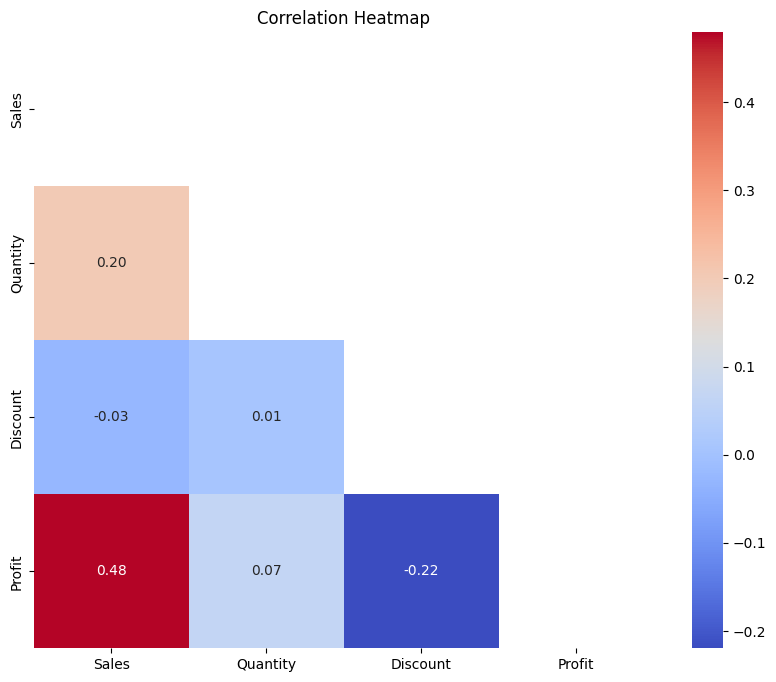

In [11]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

The correlation matrix is visualized using a heatmap to clearly represent relationships between variables. A mask is applied to the upper triangle to remove duplicate information and improve readability. The heatmap uses color gradients to indicate the strength and direction of correlations, while annotations display exact values for better interpretation.

## Pairplot

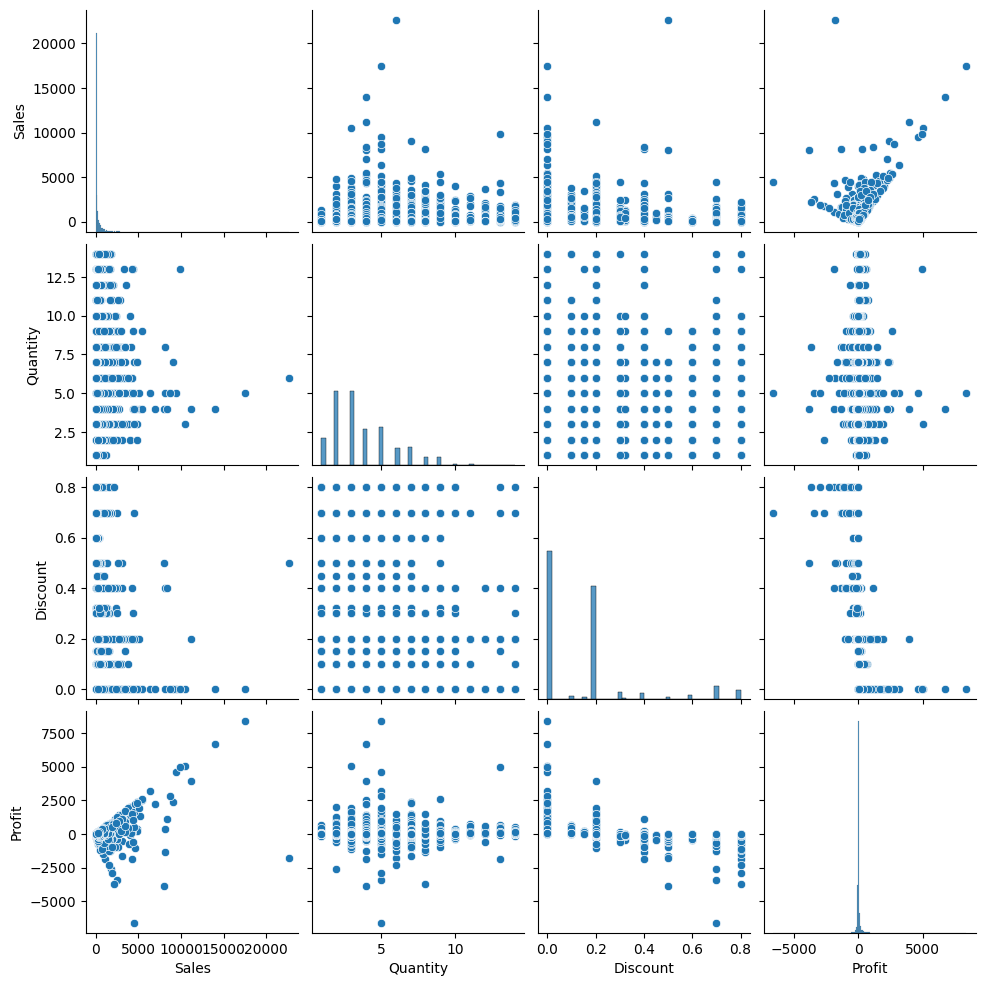

In [12]:
sns.pairplot(numeric_data)
plt.savefig("pairplot.png")
plt.show()

##  strongest positive/negative relationships


In [13]:
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1]
corr_sorted = corr_unstacked.sort_values()
print("Strongest negative:\n", corr_sorted.head(5))
print("Strongest positive:\n", corr_sorted.tail(5))

Strongest negative:
 Profit    Discount   -0.219487
Discount  Profit     -0.219487
Sales     Discount   -0.028190
Discount  Sales      -0.028190
Quantity  Discount    0.008623
dtype: float64
Strongest positive:
 Profit    Quantity    0.066253
Sales     Quantity    0.200795
Quantity  Sales       0.200795
Sales     Profit      0.479064
Profit    Sales       0.479064
dtype: float64


The correlation values were sorted to identify the strongest positive and negative relationships between variables. This helps in understanding which features are most closely related and which have inverse relationships. 
The strongest positive relationship is observed between Sales and Profit (0.48), while the strongest negative relationship is between Discount and Profit (-0.22).

### Summary

In [22]:
summary=""" 
This project analyzes the relationships between numerical variables using correlation analysis, heatmap visualization, and pairplots. The correlation matrix shows that Sales and Profit have a moderate positive relationship (0.48), indicating that higher sales generally lead to increased profit. Discount exhibits a negative correlation with Profit (-0.22), suggesting that higher discounts may reduce profitability. Other variables, such as Quantity, show weak correlations with both Sales and Profit, indicating limited influence. The heatmap provides a clear visual representation of these relationships, while the pairplot helps identify patterns and trends between variable pairs. Overall, the analysis highlights key relationships and emphasizes the impact of discounting on profit.
"""
with open("project3_summary.txt", "w") as f:
    f.write(summary)
print(summary)

 
This project analyzes the relationships between numerical variables using correlation analysis, heatmap visualization, and pairplots. The correlation matrix shows that Sales and Profit have a moderate positive relationship (0.48), indicating that higher sales generally lead to increased profit. Discount exhibits a negative correlation with Profit (-0.22), suggesting that higher discounts may reduce profitability. Other variables, such as Quantity, show weak correlations with both Sales and Profit, indicating limited influence. The heatmap provides a clear visual representation of these relationships, while the pairplot helps identify patterns and trends between variable pairs. Overall, the analysis highlights key relationships and emphasizes the impact of discounting on profit.

